In [107]:
import re
import numpy as np
import pandas as pd
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from pathlib import Path
# Plotting params
palette = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a",
    "#66a61e",
    "#e6ab02",
    "#a6761d",
    "#666666",
]

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
})


URL = "https://cdn.who.int/media/docs/default-source/gho-documents/global-health-estimates/ghe2021_daly_global_new.xlsx?sfvrsn=cbefe871_2"

def download_ghe_xlsx(url=URL, timeout=120):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return BytesIO(r.content)

def _cell_str(x):
    if x is None:
        return None
    s = str(x).strip()
    return s if s else None

def parse_global_sheet_to_taxonomy(xlsx_bytes, sheet_name="Global 2021"):
    xlsx_bytes.seek(0)
    wb = load_workbook(xlsx_bytes, data_only=True)
    ws = wb[sheet_name]

    region = _cell_str(ws.cell(3, 6).value)
    year = ws.cell(4, 6).value
    try:
        year = int(year)
    except Exception:
        year = int(re.findall(r"\d{4}", sheet_name)[0])

    lvl0_main = None
    lvl0_sub = None
    lvl1 = None
    lvl2 = None

    num_pat = re.compile(r"^\d+\.$")
    sub_pat = re.compile(r"^[A-Z]\.$")
    leaf_pat = re.compile(r"^[a-z]\.$", re.IGNORECASE)

    male_age_cols = [
        ("0_28_days", 10),
        ("1_59_months", 11),
        ("5_14", 12),
        ("15_29", 13),
        ("30_49", 14),
        ("50_59", 15),
        ("60_69", 16),
        ("70_plus", 17),
    ]
    female_age_cols = [
        ("0_28_days", 18),
        ("1_59_months", 19),
        ("5_14", 20),
        ("15_29", 21),
        ("30_49", 22),
        ("50_59", 23),
        ("60_69", 24),
        ("70_plus", 25),
    ]

    def to_num(x):
        try:
            return float(x)
        except Exception:
            return np.nan

    out = []
    for r in range(10, ws.max_row + 1):
        code = ws.cell(r, 1).value

        c3 = _cell_str(ws.cell(r, 3).value)
        c4 = _cell_str(ws.cell(r, 4).value)
        c5 = _cell_str(ws.cell(r, 5).value)
        c6 = _cell_str(ws.cell(r, 6).value)

        daly_both = to_num(ws.cell(r, 7).value)
        daly_male = to_num(ws.cell(r, 8).value)
        daly_female = to_num(ws.cell(r, 9).value)

        node = None
        level = None

        if c3 and not sub_pat.match(c3) and c4 is None and c5 is None and c6 is None:
            lvl0_main = c3
            lvl0_sub = None
            lvl1 = None
            lvl2 = None
            node = lvl0_main
            level = 0
        elif c3 and sub_pat.match(c3) and c4:
            lvl0_sub = c4
            lvl1 = None
            lvl2 = None
            node = lvl0_sub
            level = 1
        elif c4 and num_pat.match(c4) and c5:
            lvl1 = c5
            lvl2 = None
            node = lvl1
            level = 2
        elif c5 and leaf_pat.match(c5) and c6:
            lvl2 = c6
            node = lvl2
            level = 3
        else:
            continue

        row = {
            "region": region,
            "year": year,
            "sheet": sheet_name,
            "code": code,
            "level": level,
            "node": node,
            "level0_main": lvl0_main,
            "level0_sub": lvl0_sub,
            "level1": lvl1,
            "level2": lvl2,
            "daly_both_total": daly_both,
            "daly_male_total": daly_male,
            "daly_female_total": daly_female,
        }

        for tag, col in male_age_cols:
            row[f"daly_male_{tag}"] = to_num(ws.cell(r, col).value)
        for tag, col in female_age_cols:
            row[f"daly_female_{tag}"] = to_num(ws.cell(r, col).value)

        out.append(row)

    df = pd.DataFrame(out)
    df["path"] = df[["level0_main", "level0_sub", "level1", "level2"]].astype(object).agg(
        lambda x: " > ".join([v for v in x if isinstance(v, str) and v.strip()]),
        axis=1,
    )
    return df

base_palette = ["#7ab66f", "#025773", "#025773"]
extra_palette = ["#f0c808", "#f27c38", "#7b4f9d", "#2e8bc0", "#f26d7d", "#8c8c8c"]

def lighten_hex(hex_color, factor=0.35):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

def build_palette(n_colors, rotation=0):
    seed = [base_palette[0], base_palette[1], lighten_hex(base_palette[1], 0.45)]
    palette = seed + extra_palette
    if len(palette) > 0:
        rotation = rotation % len(palette)
        palette = palette[rotation:] + palette[:rotation]
    return palette[:n_colors]

def style_axes_box(ax, linewidth=0.6):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(linewidth)

def minmax01(x):
    x = pd.Series(x, dtype=float)
    if x.nunique(dropna=True) <= 1:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.min()) / (x.max() - x.min())

def zscore(x):
    x = pd.Series(x, dtype=float)
    sd = x.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.mean()) / sd


OUT_DIR = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYopportunities")


In [2]:
xlsx_bytes = download_ghe_xlsx()
tax_2021 = parse_global_sheet_to_taxonomy(xlsx_bytes, "Global 2021")
tax_2021.head()


,region,year,sheet,code,level,node,level0_main,level0_sub,level1,level2,...,daly_male_70_plus,daly_female_0_28_days,daly_female_1_59_months,daly_female_5_14,daly_female_15_29,daly_female_30_49,daly_female_50_59,daly_female_60_69,daly_female_70_plus,path
0,Global,2021,Global 2021,0,0,All Causes,All Causes,None,None,None,...,2.917125e+08,9.823325e+07,1.244504e+08,6.520948e+07,1.429846e+08,2.700881e+08,1.860011e+08,2.084319e+08,3.138755e+08,All Causes
1,Global,2021,Global 2021,10,0,"Communicable, maternal, perinatal and nutritio...","Communicable, maternal, perinatal and nutritio...",None,None,None,...,5.307556e+07,8.734841e+07,9.439322e+07,2.717642e+07,4.034541e+07,6.274173e+07,3.114981e+07,3.508791e+07,4.784674e+07,"Communicable, maternal, perinatal and nutritio..."
2,Global,2021,Global 2021,20,1,Infectious and parasitic diseases,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,None,None,...,8.672585e+06,4.659805e+06,5.905820e+07,1.463574e+07,1.447188e+07,2.167112e+07,9.712355e+06,8.049872e+06,9.888397e+06,"Communicable, maternal, perinatal and nutritio..."
3,Global,2021,Global 2021,30,2,Tuberculosis,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Tuberculosis,None,...,3.757638e+06,5.459553e+01,5.576674e+06,1.458158e+06,3.330256e+06,5.390538e+06,3.481570e+06,2.912588e+06,2.858887e+06,"Communicable, maternal, perinatal and nutritio..."
4,Global,2021,Global 2021,40,2,STDs excluding HIV,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,STDs excluding HIV,None,...,1.968129e+04,1.869393e+06,7.359206e+05,3.730480e+04,2.234408e+05,4.822917e+05,1.186005e+05,5.829581e+04,4.600198e+04,"Communicable, maternal, perinatal and nutritio..."


In [3]:
gut_terms = [
    "diarr", "gastro", "enter", "intestin", "bowel", "crohn", "colitis", "ibd",
    "ulcer", "celiac", "coeliac", "colon", "rect", "append",
    "liver", "hepat", "cirrhos", "pancrea", "gall", "bile", "cholang",
    "stomach", "gastric", "esoph", "oesoph",
]
pat = re.compile("|".join(gut_terms), flags=re.IGNORECASE)

gut_tax = tax_2021[tax_2021["path"].str.contains(pat, na=False)].copy()
gut_tax.sort_values("daly_both_total", ascending=False).head(50)

,region,year,sheet,code,level,node,level0_main,level0_sub,level1,level2,...,daly_male_70_plus,daly_female_0_28_days,daly_female_1_59_months,daly_female_5_14,daly_female_15_29,daly_female_30_49,daly_female_50_59,daly_female_60_69,daly_female_70_plus,path
12,Global,2021,Global 2021,110,2,Diarrhoeal diseases,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Diarrhoeal diseases,None,...,2.580701e+06,1.282435e+06,1.657392e+07,3.183190e+06,2.209743e+06,2.276856e+06,1.659444e+06,2.366913e+06,4.295525e+06,"Communicable, maternal, perinatal and nutritio..."
158,Global,2021,Global 2021,1230,2,Cirrhosis of the liver,Noncommunicable diseases,Digestive diseases,Cirrhosis of the liver,None,...,3.155476e+06,5.924473e+00,2.749508e+05,4.607588e+05,1.395700e+06,3.685702e+06,3.327622e+06,3.310622e+06,2.699789e+06,Noncommunicable diseases > Digestive diseases ...
71,Global,2021,Global 2021,650,2,Colon and rectum cancers,Noncommunicable diseases,Malignant neoplasms,Colon and rectum cancers,None,...,4.321255e+06,0.000000e+00,0.000000e+00,2.995766e+03,1.766086e+05,1.582422e+06,2.148968e+06,2.597068e+06,3.662872e+06,Noncommunicable diseases > Malignant neoplasms...
70,Global,2021,Global 2021,640,2,Stomach cancer,Noncommunicable diseases,Malignant neoplasms,Stomach cancer,None,...,4.205740e+06,0.000000e+00,0.000000e+00,1.848292e+03,1.430285e+05,1.257478e+06,1.572615e+06,1.917950e+06,2.396579e+06,Noncommunicable diseases > Malignant neoplasms...
138,Global,2021,Global 2021,1050,2,Uncorrected refractive errors,Noncommunicable diseases,Sense organ diseases,Uncorrected refractive errors,None,...,1.229971e+06,9.305451e+01,6.949157e+04,3.580920e+05,7.466734e+05,2.638386e+06,2.365141e+06,2.000135e+06,1.846663e+06,Noncommunicable diseases > Sense organ disease...
72,Global,2021,Global 2021,660,2,Liver cancer,Noncommunicable diseases,Malignant neoplasms,Liver cancer,None,...,2.286689e+06,0.000000e+00,3.406675e+01,2.804712e+04,1.233766e+05,8.043043e+05,1.170771e+06,1.461627e+06,1.520386e+06,Noncommunicable diseases > Malignant neoplasms...
69,Global,2021,Global 2021,630,2,Oesophagus cancer,Noncommunicable diseases,Malignant neoplasms,Oesophagus cancer,None,...,2.678665e+06,0.000000e+00,0.000000e+00,4.102805e+02,4.036558e+04,4.670607e+05,7.919815e+05,9.916658e+05,1.140401e+06,Noncommunicable diseases > Malignant neoplasms...
161,Global,2021,Global 2021,1233,3,Cirrhosis due to alcohol use,Noncommunicable diseases,Digestive diseases,Cirrhosis of the liver,Cirrhosis due to alcohol use,...,1.024865e+06,0.000000e+00,0.000000e+00,0.000000e+00,2.471439e+04,6.446094e+05,7.864457e+05,7.258414e+05,4.425160e+05,Noncommunicable diseases > Digestive diseases ...
159,Global,2021,Global 2021,1231,3,Cirrhosis due to hepatitis B,Noncommunicable diseases,Digestive diseases,Cirrhosis of the liver,Cirrhosis due to hepatitis B,...,8.781066e+05,1.764582e-03,2.278373e+03,1.682342e+04,1.803177e+05,9.060643e+05,8.000054e+05,7.516973e+05,6.681306e+05,Noncommunicable diseases > Digestive diseases ...
77,Global,2021,Global 2021,670,2,Pancreas cancer,Noncommunicable diseases,Malignant neoplasms,Pancreas cancer,None,...,2.006946e+06,0.000000e+00,0.000000e+00,5.700774e+02,2.696486e+04,4.054026e+05,9.255976e+05,1.471706e+06,2.007679e+06,Noncommunicable diseases > Malignant neoplasms...


In [4]:
import re
import pandas as pd

df = tax_2021.copy()

df["node_s"] = df["node"].astype(str)
df["path_s"] = df["path"].astype(str)

include = [
    "diarr", "inflammatory bowel", "crohn", "ulcerative colitis", "ibd",
    "colon and rectum", "colon cancer", "rectum cancer",
    "stomach cancer", "oesophagus cancer", "esophagus cancer",
    "appendicitis", "peptic ulcer", "ileus", "intestinal obstruction",
    "gastro", "enter", "intestin", "bowel"
]

exclude = [
    "liver", "hepat", "cirrhos",
    "pancrea",
    "gallbladder", "biliary", "bile", "cholang"
]

inc_pat = re.compile("|".join(include), flags=re.IGNORECASE)
exc_pat = re.compile("|".join(exclude), flags=re.IGNORECASE)

mask_inc = df["node_s"].str.contains(inc_pat, na=False) | df["path_s"].str.contains(inc_pat, na=False)
mask_exc = df["node_s"].str.contains(exc_pat, na=False) | df["path_s"].str.contains(exc_pat, na=False)

gut_tax = df[mask_inc & ~mask_exc].copy()
gut_tax


,region,year,sheet,code,level,node,level0_main,level0_sub,level1,level2,...,daly_female_1_59_months,daly_female_5_14,daly_female_15_29,daly_female_30_49,daly_female_50_59,daly_female_60_69,daly_female_70_plus,path,node_s,path_s
12,Global,2021,Global 2021,110,2,Diarrhoeal diseases,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Diarrhoeal diseases,None,...,1.657392e+07,3.183190e+06,2.209743e+06,2.276856e+06,1.659444e+06,2.366913e+06,4.295525e+06,"Communicable, maternal, perinatal and nutritio...",Diarrhoeal diseases,"Communicable, maternal, perinatal and nutritio..."
39,Global,2021,Global 2021,330,2,Intestinal nematode infections,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Intestinal nematode infections,None,...,1.802604e+05,2.584474e+05,1.982501e+05,1.956409e+05,9.688570e+04,6.958397e+04,5.267095e+04,"Communicable, maternal, perinatal and nutritio...",Intestinal nematode infections,"Communicable, maternal, perinatal and nutritio..."
40,Global,2021,Global 2021,340,3,Ascariasis,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Intestinal nematode infections,Ascariasis,...,1.364655e+05,1.092340e+05,4.432677e+04,3.215133e+04,9.435350e+03,6.480231e+03,4.381793e+03,"Communicable, maternal, perinatal and nutritio...",Ascariasis,"Communicable, maternal, perinatal and nutritio..."
41,Global,2021,Global 2021,350,3,Trichuriasis,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Intestinal nematode infections,Trichuriasis,...,4.726444e+03,2.636028e+04,3.865861e+04,1.931381e+04,3.924723e+03,2.093576e+03,1.045623e+03,"Communicable, maternal, perinatal and nutritio...",Trichuriasis,"Communicable, maternal, perinatal and nutritio..."
42,Global,2021,Global 2021,360,3,Hookworm disease,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Intestinal nematode infections,Hookworm disease,...,3.853643e+04,1.136850e+05,7.452047e+04,3.673256e+04,1.201542e+04,8.136833e+03,5.376986e+03,"Communicable, maternal, perinatal and nutritio...",Hookworm disease,"Communicable, maternal, perinatal and nutritio..."
43,Global,2021,Global 2021,362,3,Food-borne trematodes,"Communicable, maternal, perinatal and nutritio...",Infectious and parasitic diseases,Intestinal nematode infections,Food-borne trematodes,...,5.320459e+02,9.168122e+03,4.074425e+04,1.074432e+05,7.151021e+04,5.287333e+04,4.186654e+04,"Communicable, maternal, perinatal and nutritio...",Food-borne trematodes,"Communicable, maternal, perinatal and nutritio..."
69,Global,2021,Global 2021,630,2,Oesophagus cancer,Noncommunicable diseases,Malignant neoplasms,Oesophagus cancer,None,...,0.000000e+00,4.102805e+02,4.036558e+04,4.670607e+05,7.919815e+05,9.916658e+05,1.140401e+06,Noncommunicable diseases > Malignant neoplasms...,Oesophagus cancer,Noncommunicable diseases > Malignant neoplasms...
70,Global,2021,Global 2021,640,2,Stomach cancer,Noncommunicable diseases,Malignant neoplasms,Stomach cancer,None,...,0.000000e+00,1.848292e+03,1.430285e+05,1.257478e+06,1.572615e+06,1.917950e+06,2.396579e+06,Noncommunicable diseases > Malignant neoplasms...,Stomach cancer,Noncommunicable diseases > Malignant neoplasms...
71,Global,2021,Global 2021,650,2,Colon and rectum cancers,Noncommunicable diseases,Malignant neoplasms,Colon and rectum cancers,None,...,0.000000e+00,2.995766e+03,1.766086e+05,1.582422e+06,2.148968e+06,2.597068e+06,3.662872e+06,Noncommunicable diseases > Malignant neoplasms...,Colon and rectum cancers,Noncommunicable diseases > Malignant neoplasms...
157,Global,2021,Global 2021,1220,2,Peptic ulcer disease,Noncommunicable diseases,Digestive diseases,Peptic ulcer disease,None,...,2.092964e+04,8.633785e+04,2.288367e+05,4.273057e+05,4.918604e+05,6.168058e+05,9.054789e+05,Noncommunicable diseases > Digestive diseases ...,Peptic ulcer disease,Noncommunicable diseases > Digestive diseases ...


In [5]:
gut_cause = (
    gut_tax
    .dropna(subset=["daly_both_total"])
    .sort_values("daly_both_total", ascending=False)
    .drop_duplicates(subset=["code"])
    .copy()
)

gut_cause[["code", "node", "level", "level1", "level2", "daly_both_total"]]

,code,node,level,level1,level2,daly_both_total
12,110,Diarrhoeal diseases,2,Diarrhoeal diseases,None,6.974344e+07
71,650,Colon and rectum cancers,2,Colon and rectum cancers,None,2.404774e+07
70,640,Stomach cancer,2,Stomach cancer,None,2.202943e+07
69,630,Oesophagus cancer,2,Oesophagus cancer,None,1.366366e+07
165,1242,Paralytic ileus and intestinal obstruction,2,Paralytic ileus and intestinal obstruction,None,6.657518e+06
157,1220,Peptic ulcer disease,2,Peptic ulcer disease,None,6.320257e+06
39,330,Intestinal nematode infections,2,Intestinal nematode infections,None,2.307107e+06
163,1240,Appendicitis,2,Appendicitis,None,1.325560e+06
166,1244,Inflammatory bowel disease,2,Inflammatory bowel disease,None,1.296912e+06
43,362,Food-borne trematodes,3,Intestinal nematode infections,Food-borne trematodes,8.938607e+05


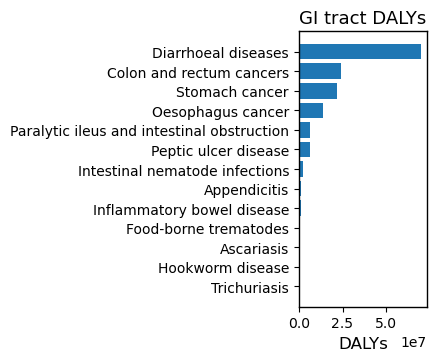

In [124]:

fig, ax = plt.subplots(figsize=(4.5, 3.75))

plot_df = gut_cause.sort_values("daly_both_total", ascending=False).head(25).iloc[::-1]

# plt.figure(figsize=())
plt.barh(plot_df["node"], plot_df["daly_both_total"])
plt.xlabel("DALYs")
# plt.ylabel("Cause")
plt.title("GI tract DALYs")
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_GIDALY.png", dpi=400, bbox_inches="tight")

In [24]:
gwas['gwas_disease'].unique()

array(['irritable_bowel_syndrome', 'inflammatory_bowel_disease',
       'diarrheal_disease', 'colorectal_cancer', 'crohns_disease',
       'abdominal_pain', 'ulcerative_colitis'], dtype=object)

In [77]:
gwas.columns

Index(['gwas', 'gwas_disease_id', 'gwas_disease', 'gwas_cohorts',
       'gwas_number', 'specificity_id', 'annotation', 'beta', 'beta_se',
       'pvalue', 'celltype', 'expression_dataset', 'gwas_dataset', 'bonf_p',
       'fdr_p', 'bonf_significant', 'fdr_significant', 'fdr_pt1_significant',
       'kept_gwas_dataset', 'hgca_celltype_level2', 'z', 'neglog10_fdr'],
      dtype='object')

In [37]:
import numpy as np
import pandas as pd

gwas_path = "/Users/kylekimler/Downloads/HGCA_all-hgca_celltype_v1_LDsc.tsv"
gwas = pd.read_csv(gwas_path, sep="\t")

for c in ["beta", "beta_se", "pvalue", "bonf_p", "fdr_p"]:
    if c in gwas.columns:
        gwas[c] = pd.to_numeric(gwas[c], errors="coerce")

gwas["z"] = gwas["beta"] / gwas["beta_se"]

if "fdr_p" in gwas.columns:
    gwas["neglog10_fdr"] = -np.log10(np.clip(gwas["fdr_p"], 1e-300, 1.0))
else:
    gwas["neglog10_fdr"] = np.nan

# if "fdr_significant" in gwas.columns:
#     sig_mask = gwas["fdr_pt1_significant"].fillna(False).astype(bool)
# else:
#     sig_mask = gwas["fdr_p"] <= 0.1

# x = gwas.loc[sig_mask].copy()

x = gwas

vuln_ct = (
    x.groupby(["gwas_disease", "gwas_disease_id", "celltype"], dropna=False)
    .agg(
        vulnerability_z=("z", lambda s: float(np.nansum(np.abs(s)))),
        vulnerability_beta=("beta", lambda s: float(np.nansum(np.abs(s)))),
        mean_abs_z=("z", lambda s: float(np.nanmean(np.abs(s)))),
        mean_abs_beta=("beta", lambda s: float(np.nanmean(np.abs(s)))),
        max_abs_z=("z", lambda s: float(np.nanmax(np.abs(s)))),
        max_abs_beta=("beta", lambda s: float(np.nanmax(np.abs(s)))),
        min_fdr_p=("fdr_p", "min"),
        mean_neglog10_fdr=("neglog10_fdr", "mean"),
        n_sig=("celltype", "size"),
    )
    .reset_index()
)

vuln_dis = (
    vuln_ct.groupby(["gwas_disease", "gwas_disease_id"], dropna=False)
    .agg(
        vulnerability_z=("vulnerability_z", "sum"),
        vulnerability_beta=("vulnerability_beta", "sum"),
        total_sig_hits=("n_sig", "sum"),
        mean_celltype_neglog10_fdr=("mean_neglog10_fdr", "mean"),
        best_celltype_fdr_p=("min_fdr_p", "min"),
    )
    .reset_index()
    .sort_values("vulnerability_z", ascending=False)
)

vuln_ct.head()

,gwas_disease,gwas_disease_id,celltype,vulnerability_z,vulnerability_beta,mean_abs_z,mean_abs_beta,max_abs_z,max_abs_beta,min_fdr_p,mean_neglog10_fdr,n_sig
0,abdominal_pain,HP_0002027,Adipocytes,1.491297,1.129338e-09,1.491297,1.129338e-09,1.491297,1.129338e-09,0.976056,0.010525,1
1,abdominal_pain,HP_0002027,Angiogenic_Pericytes,1.689000,1.358028e-09,1.689000,1.358028e-09,1.689000,1.358028e-09,0.976056,0.010525,1
2,abdominal_pain,HP_0002027,Arteriolar_Endothelial,1.146191,9.893264e-10,1.146191,9.893264e-10,1.146191,9.893264e-10,0.788710,0.103083,1
3,abdominal_pain,HP_0002027,BEST4_Colonocytes,0.540735,4.402956e-10,0.540735,4.402956e-10,0.540735,4.402956e-10,0.976056,0.010525,1
4,abdominal_pain,HP_0002027,BEST4_Enterocytes,0.089963,8.233336e-11,0.089963,8.233336e-11,0.089963,8.233336e-11,0.889954,0.050632,1


In [90]:
gwas

,gwas,gwas_disease_id,gwas_disease,gwas_cohorts,gwas_number,specificity_id,annotation,beta,beta_se,pvalue,...,gwas_dataset,bonf_p,fdr_p,bonf_significant,fdr_significant,fdr_pt1_significant,kept_gwas_dataset,hgca_celltype_level2,z,neglog10_fdr
0,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,EFO_0000555,irritable_bowel_syndrome,UKB_TwinGene,1,HGCA-all,Interstitial_Cells_of_Cajal_ICC,3.069256e-08,1.113721e-08,0.002927,...,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,0.275131,0.275131,False,False,False,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,Fibroblasts,2.755857,0.560460
1,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,EFO_0000555,irritable_bowel_syndrome,UKB_TwinGene,1,HGCA-all,Epithelial,2.294532e-08,1.080662e-08,0.016866,...,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,1.585384,0.728361,False,False,False,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,NaN,2.123266,0.137653
2,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,EFO_0000555,irritable_bowel_syndrome,UKB_TwinGene,1,HGCA-all,pDC,2.295162e-08,1.206493e-08,0.028563,...,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,2.684945,0.728361,False,False,False,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,Dendritic Cells,1.902342,0.137653
3,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,EFO_0000555,irritable_bowel_syndrome,UKB_TwinGene,1,HGCA-all,Tolerogenic_cDC2,2.397946e-08,1.308179e-08,0.033398,...,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,3.139427,0.728361,False,False,False,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,Dendritic Cells,1.833042,0.137653
4,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,EFO_0000555,irritable_bowel_syndrome,UKB_TwinGene,1,HGCA-all,Foveolar_Cells,1.563195e-08,1.027249e-08,0.064038,...,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,6.019615,0.728361,False,False,False,EFO_0000555-irritable_bowel_syndrome-UKB_TwinG...,Secretory Epithelial,1.521729,0.137653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,EFO_0000729-ulcerative_colitis-Unknown-2,EFO_0000729,ulcerative_colitis,Unknown,2,HGCA-all,Smooth_Muscle_Cells_SMC,-2.283094e-08,1.326606e-08,0.957375,...,EFO_0000729-ulcerative_colitis-Unknown-2,89.993249,0.996488,False,False,False,EFO_0000729-ulcerative_colitis-Unknown-2,Smooth Muscle Cells (SMC),-1.721004,0.001528
654,EFO_0000729-ulcerative_colitis-Unknown-2,EFO_0000729,ulcerative_colitis,Unknown,2,HGCA-all,EEC_L,-2.265058e-08,1.178301e-08,0.972716,...,EFO_0000729-ulcerative_colitis-Unknown-2,91.435348,0.996488,False,False,False,EFO_0000729-ulcerative_colitis-Unknown-2,Enteroendocrine Cells (EEC),-1.922308,0.001528
655,EFO_0000729-ulcerative_colitis-Unknown-2,EFO_0000729,ulcerative_colitis,Unknown,2,HGCA-all,Enteroendocrine_Cells_EEC,-2.334626e-08,9.785211e-09,0.991481,...,EFO_0000729-ulcerative_colitis-Unknown-2,93.199182,0.996488,False,False,False,EFO_0000729-ulcerative_colitis-Unknown-2,Enteroendocrine Cells (EEC),-2.385872,0.001528
656,EFO_0000729-ulcerative_colitis-Unknown-2,EFO_0000729,ulcerative_colitis,Unknown,2,HGCA-all,Glia,-2.804048e-08,1.081722e-08,0.995232,...,EFO_0000729-ulcerative_colitis-Unknown-2,93.551799,0.996488,False,False,False,EFO_0000729-ulcerative_colitis-Unknown-2,Glia,-2.592209,0.001528


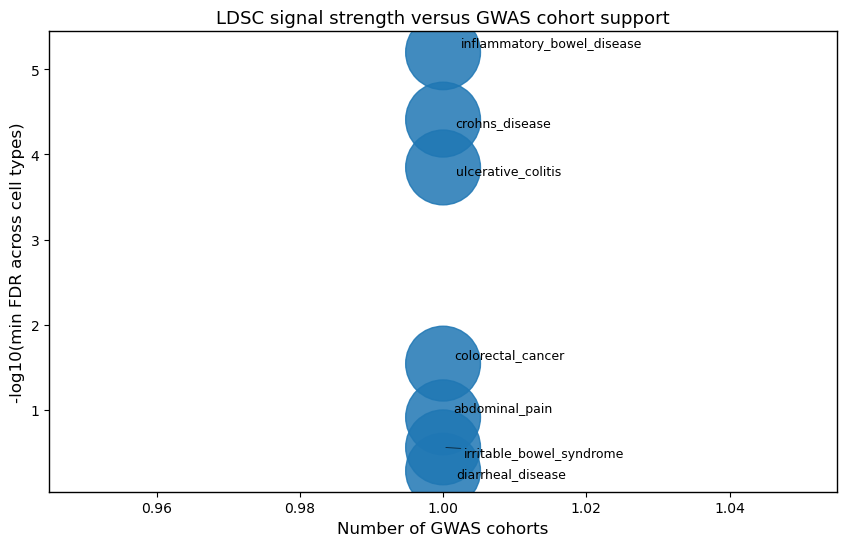

In [88]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = gwas.copy()

disease_col = "gwas_disease"
sig_col = "fdr_significant"

df["fdr_p"] = pd.to_numeric(df["fdr_p"], errors="coerce")
df[sig_col] = df[sig_col].fillna(False).astype(bool)

def count_cohorts(x):
    if pd.isna(x):
        return 0
    s = str(x).strip()
    if s == "":
        return 0
    parts = re.split(r"[|;,/]+", s)
    parts = [p.strip() for p in parts if p.strip()]
    return len(set(parts))

tmp = df[[disease_col, "gwas_dataset", "fdr_p", sig_col, "celltype"]].copy()
tmp["n_cohorts_row"] = tmp["gwas_dataset"].map(count_cohorts)

disease_summary = (
    tmp.groupby(disease_col)
    .agg(
        n_cohorts=("n_cohorts_row", "max"),
        n_sig_hits=(sig_col, "sum"),
        n_tested_celltypes=("celltype", "nunique"),
        min_fdr=("fdr_p", "min")
    )
    .reset_index()
)

disease_summary["signal_strength"] = -np.log10(
    np.clip(disease_summary["min_fdr"], 1e-300, 1.0)
)

sizes = 80 + 30 * disease_summary["n_tested_celltypes"].fillna(0)

fig, ax = plt.subplots(figsize=(8.6, 5.6))

ax.scatter(
    disease_summary["n_cohorts"],
    disease_summary["signal_strength"],
    s=sizes,
    alpha=0.85
)

texts = []
for _, r in disease_summary.iterrows():
    txt = ax.text(
        r["n_cohorts"],
        r["signal_strength"],
        str(r[disease_col]),
        fontsize=9
    )
    texts.append(txt)

try:
    from adjustText import adjust_text
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.7)
    )
except ImportError:
    print("adjustText not installed. Run: pip install adjustText")

ax.set_xlabel("Number of GWAS cohorts")
ax.set_ylabel("-log10(min FDR across cell types)")
ax.set_title("LDSC signal strength versus GWAS cohort support")

plt.tight_layout()
plt.show()

In [101]:
merged

,gwas_disease,gwas_disease_id,vulnerability_z,vulnerability_beta,total_sig_hits,mean_celltype_neglog10_fdr,best_celltype_fdr_p,who_cause,daly,node_norm
0,crohns_disease,EFO_0000384,163.141163,4.842402e-06,94,0.723582,0.000039,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
1,inflammatory_bowel_disease,EFO_0003767,139.790946,3.183528e-06,94,0.771678,0.000006,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
2,ulcerative_colitis,EFO_0000729,132.161260,2.800489e-06,94,0.660598,0.000143,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
3,colorectal_cancer,MONDO_0005575,131.411745,1.604269e-06,94,0.362276,0.028615,Colon and rectum cancers,2.404774e+07,colon and rectum cancers
4,irritable_bowel_syndrome,EFO_0000555,86.378746,8.497521e-07,94,0.072002,0.275131,None,NaN,NaN
5,abdominal_pain,HP_0002027,83.792023,7.230554e-08,94,0.105039,0.122139,None,NaN,NaN
6,diarrheal_disease,MONDO_0001673,72.462423,7.520969e-08,94,0.074952,0.518240,Diarrhoeal diseases,6.974344e+07,diarrhoeal diseases


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_67840/3280024430.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['gwas_disease'], rotation=45, ha="right")


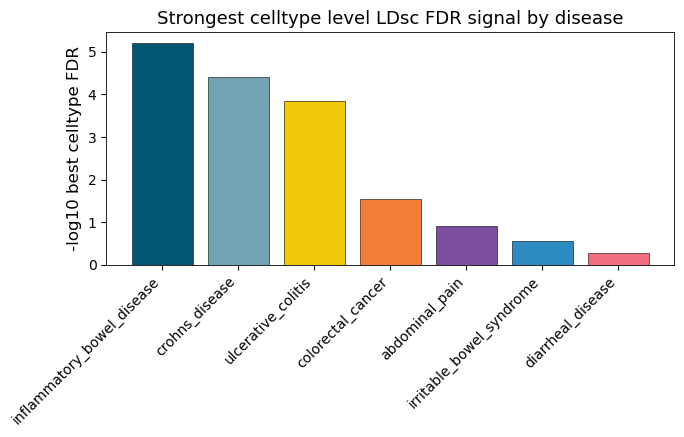

In [120]:
plot_df = merged.copy()

plot_df["neglog10_best_celltype_fdr"] = -np.log10(
    np.clip(plot_df["best_celltype_fdr_p"].astype(float), 1e-300, 1.0)
)

plot_df = plot_df.sort_values("neglog10_best_celltype_fdr", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(
    plot_df["gwas_disease"],
    plot_df["neglog10_best_celltype_fdr"],
    color=build_palette(len(plot_df), rotation=1),
    edgecolor="black",
    linewidth=0.4,
)

ax.set_xlabel("")
ax.set_ylabel("-log10 best celltype FDR")
ax.set_title("Strongest celltype level LDsc FDR signal by disease")
ax.set_xticklabels(plot_df['gwas_disease'], rotation=45, ha="right")
# ax.set_xticklabels(rotation=45, )
style_axes_box(ax)
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_LDsc_best_significance_per_disease.png", dpi=400, bbox_inches="tight")

In [38]:
x['gwas_disease'].unique()

array(['irritable_bowel_syndrome', 'inflammatory_bowel_disease',
       'diarrheal_disease', 'colorectal_cancer', 'crohns_disease',
       'abdominal_pain', 'ulcerative_colitis'], dtype=object)

In [39]:
def norm(s):
    return str(s).lower().strip()

who_nodes = gut_cause[["node", "daly_both_total"]].copy()
who_nodes["node_norm"] = who_nodes["node"].map(norm)

override = {
    "crohns_disease": "Inflammatory bowel disease",
    "crohn's disease": "Inflammatory bowel disease",
    "ulcerative_colitis": "Inflammatory bowel disease",
    "ulcerative colitis": "Inflammatory bowel disease",
    "inflammatory_bowel_disease": "Inflammatory bowel disease",
    "ibd": "Inflammatory bowel disease",
    "colorectal cancer": "Colon and rectum cancers",
    "colon cancer": "Colon and rectum cancers",
    "rectal cancer": "Colon and rectum cancers",
    "diarrhea": "Diarrheal diseases",
    "diarrheal": "Diarrheal diseases",
    "diarrhoea": "Diarrheal diseases",
}

def map_gwas_to_who(gwas_name):
    s = norm(gwas_name)
    if s in override:
        return override[s]
    if "crohn" in s or "ulcerative" in s or "colitis" in s or "ibd" in s:
        return "Inflammatory bowel disease"
    if "colorect" in s or ("colon" in s and "cancer" in s) or ("rect" in s and "cancer" in s):
        return "Colon and rectum cancers"
    if "stomach" in s and "cancer" in s:
        return "Stomach cancer"
    if ("oesoph" in s or "esoph" in s) and "cancer" in s:
        return "Oesophagus cancer"
    if "diarr" in s:
        return "Diarrhoeal diseases"
    if "appendic" in s:
        return "Appendicitis"
    if "ulcer" in s:
        return "Peptic ulcer disease"
    if "ileus" in s or "obstruction" in s:
        return "Paralytic ileus and intestinal obstruction"
    if "nematode" in s or "helminth" in s or "hookworm" in s or "ascar" in s or "trichur" in s:
        return "Intestinal nematode infections"
    return None

vmap = vuln_dis.copy()
vmap["who_cause"] = vmap["gwas_disease"].map(map_gwas_to_who)

merged = vmap.merge(
    who_nodes.rename(columns={"node": "who_cause", "daly_both_total": "daly"}),
    on="who_cause",
    how="left",
)

merged.sort_values("vulnerability_beta", ascending=False).head(30)


,gwas_disease,gwas_disease_id,vulnerability_z,vulnerability_beta,total_sig_hits,mean_celltype_neglog10_fdr,best_celltype_fdr_p,who_cause,daly,node_norm
0,crohns_disease,EFO_0000384,163.141163,4.842402e-06,94,0.723582,0.000039,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
1,inflammatory_bowel_disease,EFO_0003767,139.790946,3.183528e-06,94,0.771678,0.000006,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
2,ulcerative_colitis,EFO_0000729,132.161260,2.800489e-06,94,0.660598,0.000143,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
3,colorectal_cancer,MONDO_0005575,131.411745,1.604269e-06,94,0.362276,0.028615,Colon and rectum cancers,2.404774e+07,colon and rectum cancers
4,irritable_bowel_syndrome,EFO_0000555,86.378746,8.497521e-07,94,0.072002,0.275131,None,NaN,NaN
6,diarrheal_disease,MONDO_0001673,72.462423,7.520969e-08,94,0.074952,0.518240,Diarrhoeal diseases,6.974344e+07,diarrhoeal diseases
5,abdominal_pain,HP_0002027,83.792023,7.230554e-08,94,0.105039,0.122139,None,NaN,NaN


In [30]:
vuln_dis

,gwas_disease,gwas_disease_id,vulnerability_z,vulnerability_beta,total_sig_hits,mean_celltype_neglog10_fdr,best_celltype_fdr_p
2,inflammatory_bowel_disease,EFO_0003767,82.109753,2.278868e-06,24,2.676426,0.000006
1,crohns_disease,EFO_0000384,76.442187,2.920224e-06,23,2.468290,0.000039
3,ulcerative_colitis,EFO_0000729,53.920957,1.414782e-06,16,2.380504,0.000143
0,colorectal_cancer,MONDO_0005575,30.937367,3.416494e-07,11,1.374320,0.028615


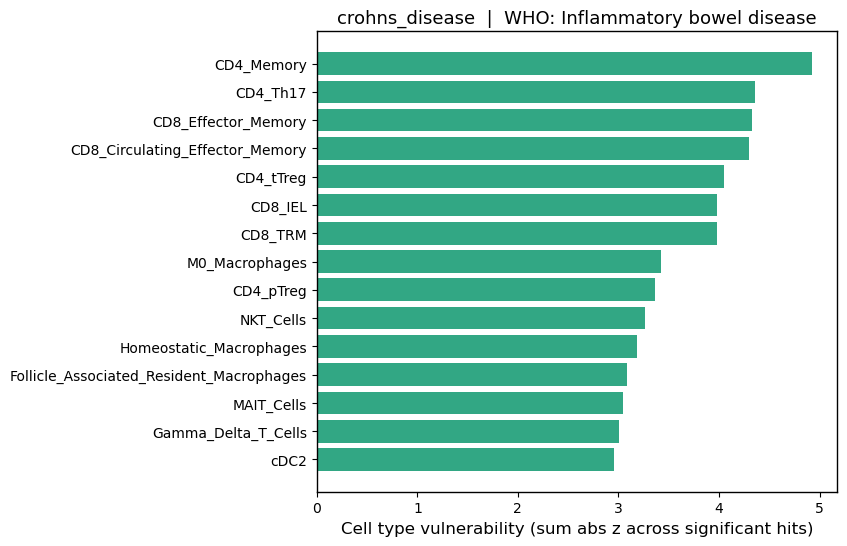

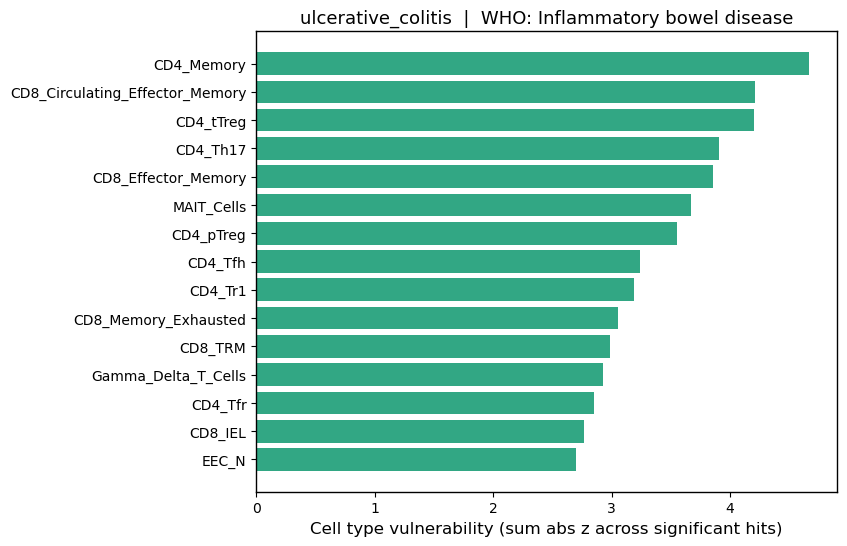

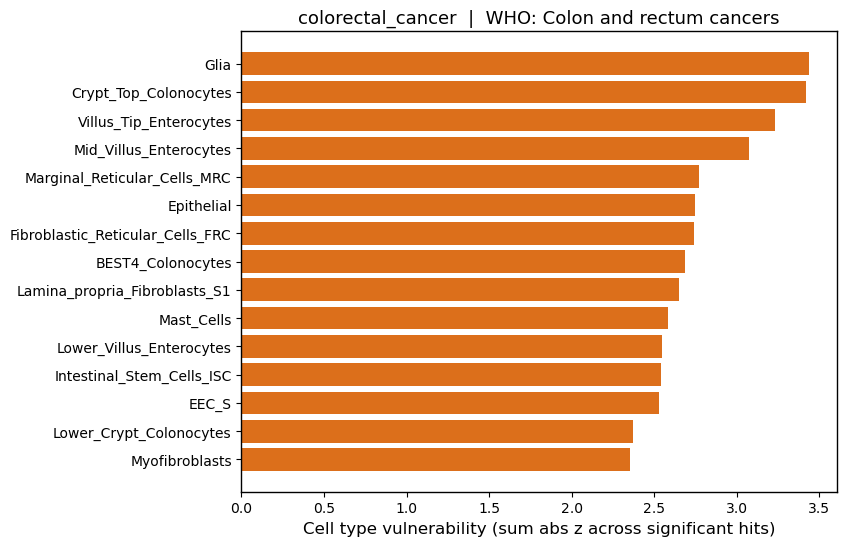

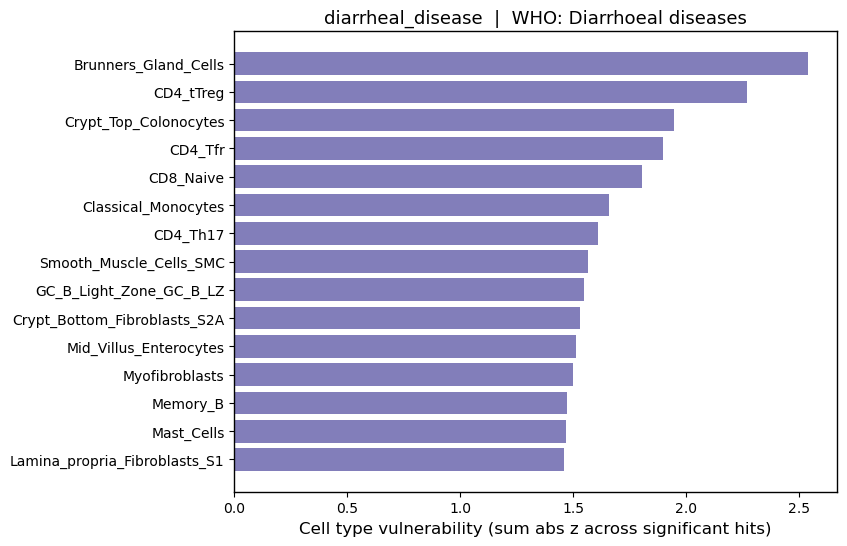

In [53]:
cause_to_color = {}
unique_causes = [c for c in merged["who_cause"].dropna().unique().tolist()]

for i, c in enumerate(unique_causes):
    cause_to_color[c] = palette[i % len(palette)]

top_celltypes_per_disease = 15

mapped_diseases = merged.dropna(subset=["who_cause"]).sort_values("vulnerability_z", ascending=False)
mapped_diseases = mapped_diseases["gwas_disease"].tolist()

mapped_diseases.pop(1)

for dis in mapped_diseases:
    who_cause = merged.loc[merged["gwas_disease"] == dis, "who_cause"].iloc[0]
    color = cause_to_color.get(who_cause, "#666666")

    sub = vuln_ct[vuln_ct["gwas_disease"] == dis].sort_values("vulnerability_z", ascending=False).head(top_celltypes_per_disease)
    if sub.shape[0] == 0:
        continue

    sub = sub.iloc[::-1].copy()

    plt.figure(figsize=(8.6, 5.6))
    plt.barh(sub["celltype"], sub["vulnerability_z"], color=color, alpha=0.9)
    plt.xlabel("Cell type vulnerability (sum abs z across significant hits)")
    plt.ylabel("")
    plt.title(f"{dis}  |  WHO: {who_cause}")
    plt.tight_layout()
    plt.show()


In [18]:
merged

,gwas_disease,gwas_disease_id,vulnerability_z,vulnerability_beta,total_sig_hits,mean_celltype_neglog10_fdr,best_celltype_fdr_p,who_cause,daly,node_norm
0,inflammatory_bowel_disease,EFO_0003767,82.109753,2.278868e-06,24,2.676426,0.000006,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
1,crohns_disease,EFO_0000384,76.442187,2.920224e-06,23,2.468290,0.000039,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
2,ulcerative_colitis,EFO_0000729,53.920957,1.414782e-06,16,2.380504,0.000143,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
3,colorectal_cancer,MONDO_0005575,30.937367,3.416494e-07,11,1.374320,0.028615,Colon and rectum cancers,2.404774e+07,colon and rectum cancers


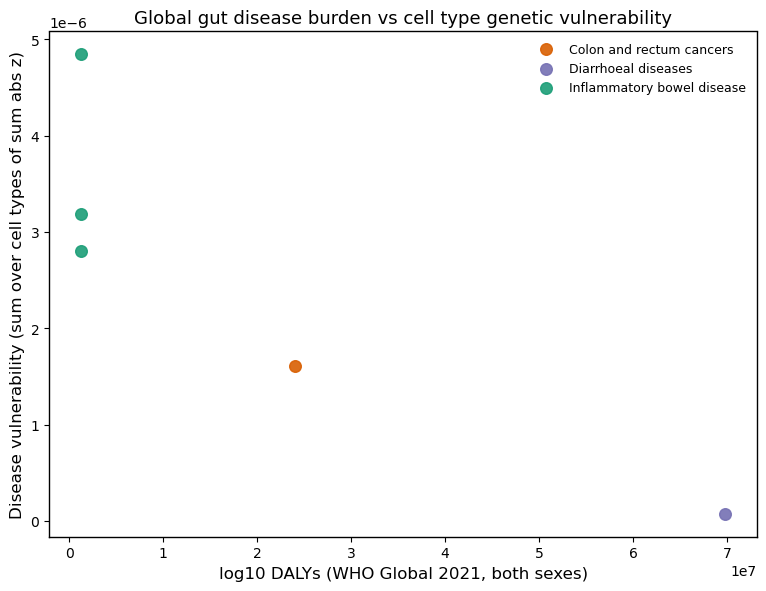

In [41]:
plt.figure(figsize=(7.8, 6.2))

for who_cause, grp in merged.groupby("who_cause"):
    plt.scatter(grp["daly"], grp["vulnerability_beta"], s=70, alpha=0.9, color=cause_to_color.get(who_cause, "#666666"), label=who_cause)

plt.xlabel("log10 DALYs (WHO Global 2021, both sexes)")
plt.ylabel("Disease vulnerability (sum over cell types of sum abs z)")
plt.title("Global gut disease burden vs cell type genetic vulnerability")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


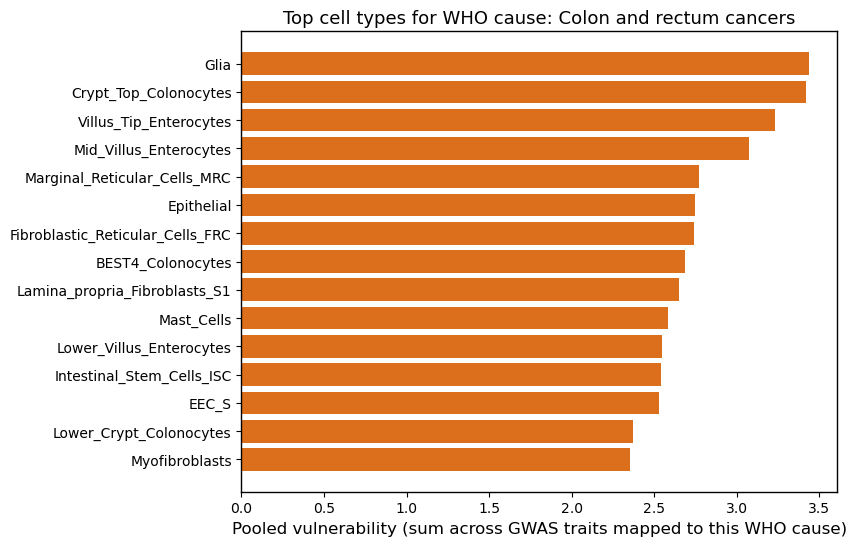

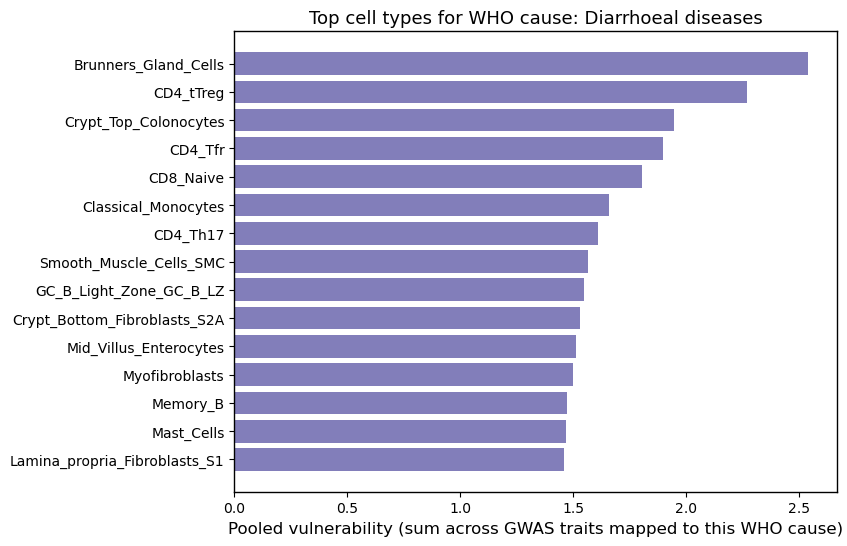

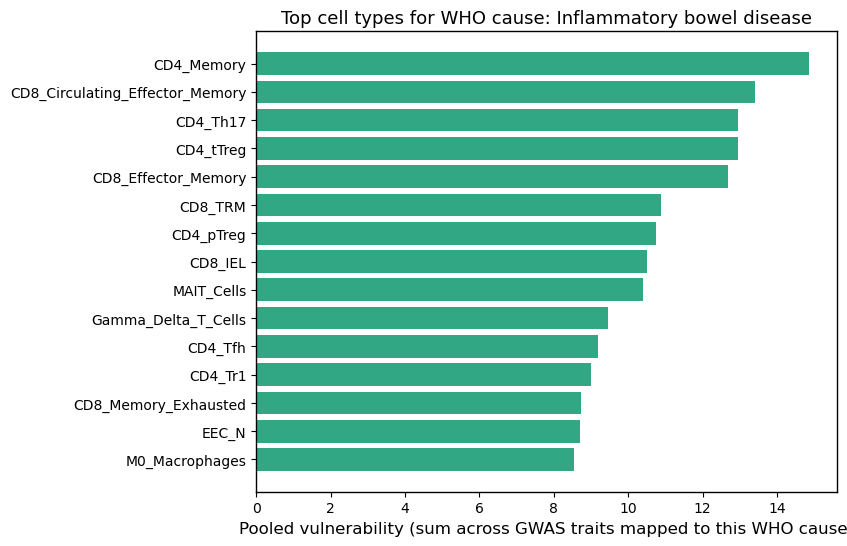

In [42]:
mapped = vuln_ct.merge(
    merged[["gwas_disease", "who_cause"]],
    on="gwas_disease",
    how="inner",
)

cause_ct = (
    mapped.dropna(subset=["who_cause"])
    .groupby(["who_cause", "celltype"], dropna=False)["vulnerability_z"]
    .sum()
    .reset_index()
)

for who_cause in sorted(cause_ct["who_cause"].dropna().astype(str).unique().tolist()):
    sub = (
        cause_ct[cause_ct["who_cause"] == who_cause]
        .sort_values("vulnerability_z", ascending=False)
        .head(15)
        .iloc[::-1]
        .copy()
    )

    plt.figure(figsize=(8.6, 5.6))
    plt.barh(sub["celltype"], sub["vulnerability_z"], color=cause_to_color.get(who_cause, "#666666"), alpha=0.9)
    plt.xlabel("Pooled vulnerability (sum across GWAS traits mapped to this WHO cause)")
    plt.ylabel("")
    plt.title(f"Top cell types for WHO cause: {who_cause}")
    plt.tight_layout()
    plt.show()


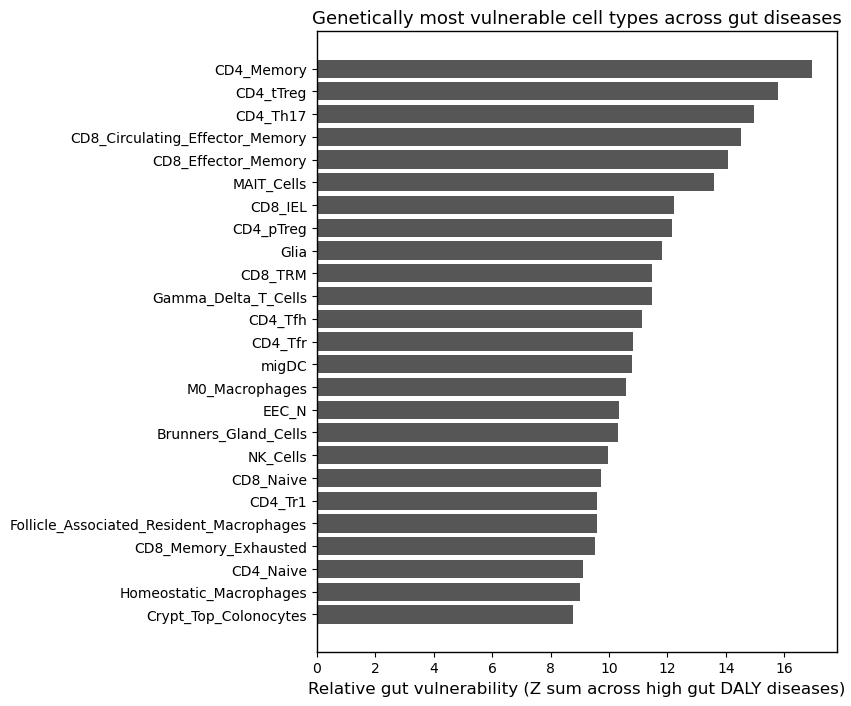

In [119]:
overall_ct = (
    mapped.dropna(subset=["who_cause"])
    .groupby("celltype", dropna=False)["vulnerability_z"]
    .sum()
    .reset_index()
    .sort_values("vulnerability_z", ascending=False)
)

top_n = 25
sub = overall_ct.head(top_n).iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(8.6, 7.2))

plt.barh(sub["celltype"], sub["vulnerability_z"], color="#444444", alpha=0.9)
plt.xlabel("Relative gut vulnerability (Z sum across high gut DALY diseases)")
plt.ylabel("")
plt.title("Genetically most vulnerable cell types across gut diseases")
plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_vulnerability_across_DALY_diseases.png", dpi=400, bbox_inches="tight")

In [72]:
vuln_ct.to_csv("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYgeneticVulnerabilities/GCAvulnerability.csv")

vuln_ct

,gwas_disease,gwas_disease_id,celltype,vulnerability_z,vulnerability_beta,mean_abs_z,mean_abs_beta,max_abs_z,max_abs_beta,min_fdr_p,mean_neglog10_fdr,n_sig
0,abdominal_pain,HP_0002027,Adipocytes,1.491297,1.129338e-09,1.491297,1.129338e-09,1.491297,1.129338e-09,0.976056,0.010525,1
1,abdominal_pain,HP_0002027,Angiogenic_Pericytes,1.689000,1.358028e-09,1.689000,1.358028e-09,1.689000,1.358028e-09,0.976056,0.010525,1
2,abdominal_pain,HP_0002027,Arteriolar_Endothelial,1.146191,9.893264e-10,1.146191,9.893264e-10,1.146191,9.893264e-10,0.788710,0.103083,1
3,abdominal_pain,HP_0002027,BEST4_Colonocytes,0.540735,4.402956e-10,0.540735,4.402956e-10,0.540735,4.402956e-10,0.976056,0.010525,1
4,abdominal_pain,HP_0002027,BEST4_Enterocytes,0.089963,8.233336e-11,0.089963,8.233336e-11,0.089963,8.233336e-11,0.889954,0.050632,1
...,...,...,...,...,...,...,...,...,...,...,...,...
653,ulcerative_colitis,EFO_0000729,Villus_Tip_Enterocytes,0.931343,1.329450e-08,0.931343,1.329450e-08,0.931343,1.329450e-08,0.393543,0.405008,1
654,ulcerative_colitis,EFO_0000729,cDC1,1.128664,2.563671e-08,1.128664,2.563671e-08,1.128664,2.563671e-08,0.330194,0.481230,1
655,ulcerative_colitis,EFO_0000729,cDC2,1.284089,3.049152e-08,1.284089,3.049152e-08,1.284089,3.049152e-08,0.283582,0.547321,1
656,ulcerative_colitis,EFO_0000729,migDC,2.411031,7.273221e-08,2.411031,7.273221e-08,2.411031,7.273221e-08,0.046728,1.330420,1


In [75]:
merged.to_csv("/Users/kylekimler/Projects/GCA/github_vignette_output/DALYgeneticVulnerabilities/DALYtable.csv")

merged



,gwas_disease,gwas_disease_id,vulnerability_z,vulnerability_beta,total_sig_hits,mean_celltype_neglog10_fdr,best_celltype_fdr_p,who_cause,daly,node_norm
0,crohns_disease,EFO_0000384,163.141163,4.842402e-06,94,0.723582,0.000039,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
1,inflammatory_bowel_disease,EFO_0003767,139.790946,3.183528e-06,94,0.771678,0.000006,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
2,ulcerative_colitis,EFO_0000729,132.161260,2.800489e-06,94,0.660598,0.000143,Inflammatory bowel disease,1.296912e+06,inflammatory bowel disease
3,colorectal_cancer,MONDO_0005575,131.411745,1.604269e-06,94,0.362276,0.028615,Colon and rectum cancers,2.404774e+07,colon and rectum cancers
4,irritable_bowel_syndrome,EFO_0000555,86.378746,8.497521e-07,94,0.072002,0.275131,None,NaN,NaN
5,abdominal_pain,HP_0002027,83.792023,7.230554e-08,94,0.105039,0.122139,None,NaN,NaN
6,diarrheal_disease,MONDO_0001673,72.462423,7.520969e-08,94,0.074952,0.518240,Diarrhoeal diseases,6.974344e+07,diarrhoeal diseases


## vulnerability x druggability


=== vedolizumab ===
Resolved ID: CHEMBL1743087
Approved: True
Max phase: 4


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000115232,ITGA4
1,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000139626,ITGB7



=== linaclotide ===
Resolved ID: CHEMBL3301675
Approved: True
Max phase: 4


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,LINACLOTIDE,AGONIST,Heat-stable enterotoxin receptor agonist,ENSG00000070019,GUCY2C
